In [1]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, utils
import matplotlib.pyplot as plt

from models.cvqvae import CVQVAE

In [2]:
# ----- 设置设备 -----
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----- 数据预处理 -----
transform = transforms.Compose([
    transforms.Resize((256, 256)),  # Upscale CIFAR-10 from 32x32 to 256x256
    transforms.ToTensor(),
])

test_dataset = datasets.CIFAR10(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=True)

# ----- 加载模型 -----
model = CVQVAE(num_embeddings=512, embedding_dim=64).to(device)
model.eval()

100%|██████████| 170M/170M [00:04<00:00, 34.5MB/s] 


Extracting ./data\cifar-10-python.tar.gz to ./data


CVQVAE(
  (encoder): Encoder(
    (net): Sequential(
      (0): Conv2d(3, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): Conv2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(128, 64, kernel_size=(1, 1), stride=(1, 1))
    )
  )
  (vq): VectorQuantizer(
    (embedding): Embedding(512, 64)
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): ConvTranspose2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (1): ReLU()
      (2): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (3): ReLU()
      (4): Conv2d(128, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): Sigmoid()
    )
  )
)

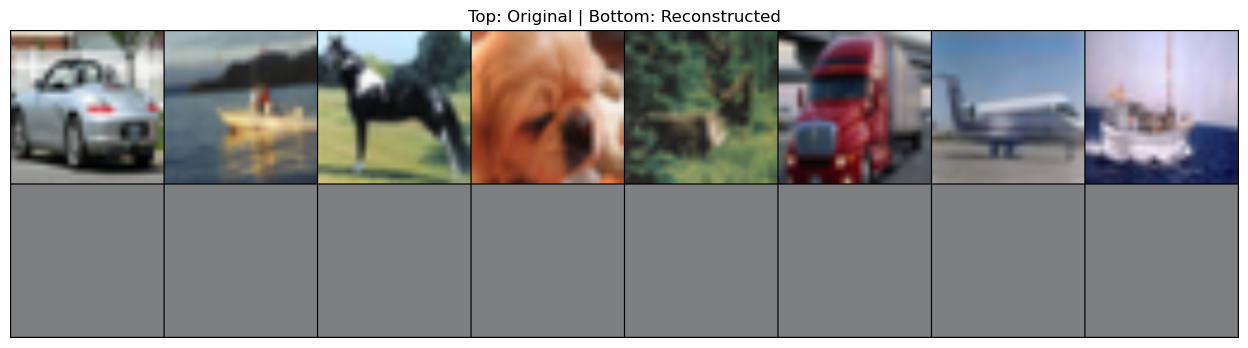

In [3]:





# ----- 可视化重建效果 -----
def visualize_reconstruction():
    data, _ = next(iter(test_loader))
    data = data.to(device)

    with torch.no_grad():
        recon, _ = model(data, data)

    grid = utils.make_grid(torch.cat([data.cpu(), recon.cpu()], dim=0), nrow=8)
    plt.figure(figsize=(16, 4))
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.title("Top: Original | Bottom: Reconstructed")
    plt.show()

if __name__ == "__main__":
    visualize_reconstruction()
